# 03 — Gradient-Based Beam Steering with JAX

Raytrax is built on [JAX](https://docs.jax.dev), which means the entire ray tracer is **automatically differentiable**. You can compute exact gradients of any scalar loss (absorbed power, deposition location, …) with respect to beam parameters — no finite-difference approximations needed.

This notebook demonstrates:

1. Differentiating through `raytrax.trace` with `jax.grad`
2. Validating against finite differences
3. Running a simple gradient-ascent loop to steer a beam for maximum absorption

> **Hardware note:** The first `jax.grad` call triggers JIT compilation and may take several seconds. Subsequent calls are fast.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from raytrax import Beam, MagneticConfiguration, RadialProfiles, trace

## 1 · Synthetic tokamak (same as notebook 01)

We reuse the analytic circular tokamak so this notebook is self-contained.

In [2]:
R0, a, B0 = 3.0, 1.0, 2.5
n_R, n_Z = 50, 60

R_grid = jnp.linspace(R0 - 1.5 * a, R0 + 1.5 * a, n_R)
Z_grid = jnp.linspace(-1.5 * a, 1.5 * a, n_Z)
R_2d, Z_2d = jnp.meshgrid(R_grid, Z_grid, indexing="ij")

phi_grid = jnp.array([0.0])
rphiz = jnp.stack(jnp.meshgrid(R_grid, phi_grid, Z_grid, indexing="ij"), axis=-1)

B_phi = B0 * R0 / R_2d
rho_2d = jnp.sqrt((R_2d - R0) ** 2 + Z_2d**2) / a
rho_1d = jnp.linspace(0, 1, 200)

mag_conf = MagneticConfiguration(
    rphiz=rphiz,
    magnetic_field=jnp.stack(
        [jnp.zeros_like(R_2d), B_phi, jnp.zeros_like(R_2d)], axis=-1
    )[:, jnp.newaxis, :, :],
    rho=rho_2d[:, jnp.newaxis, :],
    nfp=1,
    is_stellarator_symmetric=False,
    rho_1d=rho_1d,
    dvolume_drho=4.0 * jnp.pi**2 * R0 * a**2 * rho_1d,
    is_axisymmetric=True,
)

profiles = RadialProfiles(
    rho=rho_1d,
    electron_density=0.5 * (1.0 - rho_1d**2),
    electron_temperature=3.0 * (1.0 - rho_1d**2),
)

# Fixed launch point on the outer midplane
position_ref = jnp.array([R0 + 1.5 * a, 0.0, 0.0])

## 2 · Differentiable loss functions

We parametrise the beam direction in the poloidal R–Z plane by a single angle $\theta$:
$$\hat{d}(\theta) = (-\cos\theta,\; 0,\; \sin\theta)$$

Keeping $N_y = 0$ avoids a known numerical instability ($\tan\theta \to \infty$) when the out-of-plane component drifts.

Two loss functions:
- `absorbed_fraction(θ)` — total absorbed power fraction $1 - e^{-\tau}$
- `deposition_centroid(θ, ρ^*)` — Gaussian-weighted centroid near a target flux surface $\rho^*$

In [3]:
def make_beam(theta: jax.Array) -> Beam:
    """Beam parametrised by poloidal angle θ (radians)."""
    direction = jnp.array([-jnp.cos(theta), 0.0, jnp.sin(theta)])
    return Beam(
        position=position_ref,
        direction=direction,
        frequency=jnp.array(140e9),
        mode="O",
        power=1e6,
    )


@jax.jit
def absorbed_fraction(theta: jax.Array) -> jax.Array:
    """Total absorbed power fraction 1 − exp(−τ)."""
    result = trace(mag_conf, profiles, make_beam(theta), trim=False)
    tau = jnp.max(
        jnp.where(
            jnp.isfinite(result.beam_profile.optical_depth),
            result.beam_profile.optical_depth,
            0.0,
        )
    )
    return 1.0 - jnp.exp(-tau)


@jax.jit
def deposition_centroid(theta: jax.Array, target_rho: float = 0.4) -> jax.Array:
    """Gaussian-weighted linear power density centred at target_rho.

    Maximising this steers the deposition peak towards the chosen flux surface.
    """
    result = trace(mag_conf, profiles, make_beam(theta), trim=False)
    rho_traj = result.beam_profile.normalized_effective_radius
    lpd = result.beam_profile.linear_power_density
    w = jnp.exp(-(((rho_traj - target_rho) / 0.1) ** 2))
    return jnp.sum(lpd * w)

## 3 · Forward pass & gradient

Compute the loss and its gradient at $\theta = 0.3$ rad. Then validate the AD gradient against a central finite difference.

In [4]:
theta0 = jnp.array(0.3)  # initial poloidal angle [rad]

# Forward
p0 = float(absorbed_fraction(theta0))
print(f"Absorbed fraction at θ={float(theta0):.2f} rad : {p0:.4f}")

# Automatic differentiation
grad_ad = float(jax.grad(absorbed_fraction)(theta0))
print(f"AD gradient  dP/dθ = {grad_ad:.4f}")

# Central finite difference validation
eps = 1e-5
grad_fd = (
    float(absorbed_fraction(theta0 + eps)) - float(absorbed_fraction(theta0 - eps))
) / (2 * eps)
print(f"FD gradient  dP/dθ = {grad_fd:.4f}  (ε = {eps})")
print(f"Relative error     = {abs(grad_ad - grad_fd) / (abs(grad_fd) + 1e-12):.2e}")

Absorbed fraction at θ=0.30 rad : 0.1799
AD gradient  dP/dθ = -1.1525
FD gradient  dP/dθ = -1.2100  (ε = 1e-05)
Relative error     = 4.75e-02


## 4 · Gradient ascent: maximise absorbed fraction

We run 25 gradient-ascent steps to find the poloidal beam angle that maximises total absorption.

In [5]:
value_and_grad = jax.jit(jax.value_and_grad(absorbed_fraction))

lr = 0.05
theta = jnp.array(0.3)
n_steps = 25

history_p = []
history_theta = []

for step in range(n_steps):
    p_val, g = value_and_grad(theta)
    history_p.append(float(p_val))
    history_theta.append(float(theta))
    theta = theta + lr * g

print(
    f"Final θ             = {float(theta):.4f} rad = {float(theta) * 180 / np.pi:.2f}°"
)
print(f"Final absorbed frac = {float(absorbed_fraction(theta)):.4f}")

Final θ             = 0.0121 rad = 0.70°
Final absorbed frac = 0.3722


## 5 · Optimization trajectory

Plot how absorbed power fraction and beam angle evolve over the gradient-ascent steps, and compare the beam traces before and after optimization.

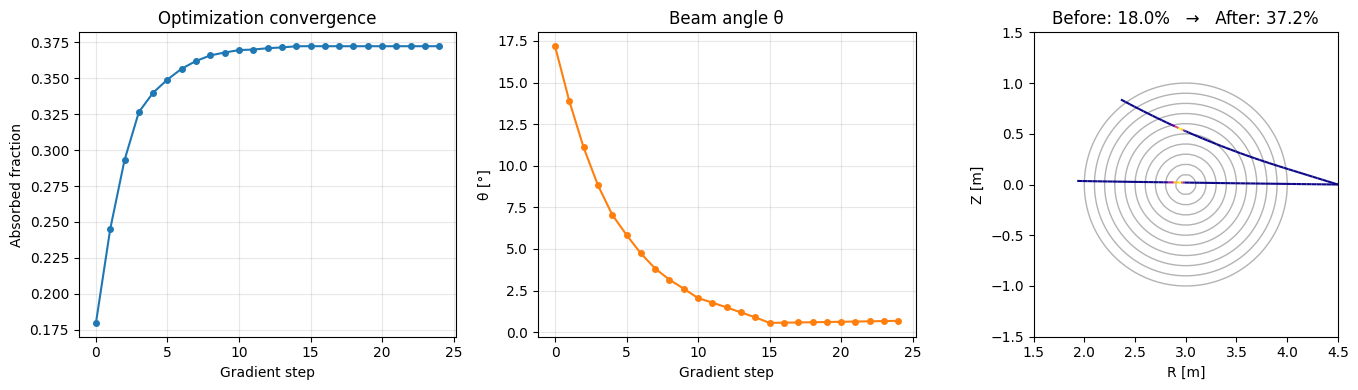

In [6]:
from raytrax.plot.plot2d import plot_beamtrace_rz, plot_effective_radius_rz

theta_init = jnp.array(history_theta[0])
theta_opt = theta

result_init = trace(mag_conf, profiles, make_beam(theta_init))
result_opt = trace(mag_conf, profiles, make_beam(theta_opt))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# — Convergence curves —
steps = np.arange(n_steps)
axes[0].plot(steps, history_p, "o-", color="C0", ms=4)
axes[0].set_xlabel("Gradient step")
axes[0].set_ylabel("Absorbed fraction")
axes[0].grid(alpha=0.3)
axes[0].set_title("Optimization convergence")

axes[1].plot(steps, np.rad2deg(history_theta), "o-", color="C1", ms=4)
axes[1].set_xlabel("Gradient step")
axes[1].set_ylabel("θ [°]")
axes[1].grid(alpha=0.3)
axes[1].set_title("Beam angle θ")

# — Before / after beam traces —
plot_effective_radius_rz(mag_conf, phi=0.0, ax=axes[2])
plot_beamtrace_rz(
    result_init.beam_profile,
    phi=0.0,
    ax=axes[2],
    lw=1.5,
    label="initial",
    add_colorbar=False,
)
plot_beamtrace_rz(
    result_opt.beam_profile,
    phi=0.0,
    ax=axes[2],
    lw=1.5,
    label="optimised",
    add_colorbar=False,
)
axes[2].set_title(
    f"Before: {result_init.absorbed_power_fraction:.1%}   →   "
    f"After: {result_opt.absorbed_power_fraction:.1%}"
)

plt.tight_layout()
plt.show()